# 04_02 Classification - RandomForest
Train and evaluate RandomForestClassifier.

[COMMAND_SO]
Command 1

[COMMAND_MUC_DICH]
- Muc tieu nghiep vu: Train RandomForestClassifier va visual output tren test set.
- Muc tieu ky thuat: Hien thi bang metric va confusion matrix ngay trong notebook.

26/03/31 22:23:25 WARN Utils: Your hostname, Genius-Macbook.local resolves to a loopback address: 127.0.0.1; using 192.168.2.18 instead (on interface en0)
26/03/31 22:23:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/03/31 22:23:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/03/31 22:23:26 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/31 22:23:26 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


26/03/31 22:23:34 WARN DAGScheduler: Broadcasting large task binary with size 1080.6 KiB


26/03/31 22:23:35 WARN DAGScheduler: Broadcasting large task binary with size 1256.5 KiB


{'model_family': 'classification', 'model_name': 'RandomForestClassifier', 'val_f1': 0.687444146712019, 'val_accuracy': 0.7777328480927349, 'f1': 0.6946506391668849, 'accuracy': 0.7829949238578681, 'test_f1': 0.6946506391668849, 'test_accuracy': 0.7829949238578681, 'train_rows': 69631, 'val_rows': 14838, 'test_rows': 14972}


,model_family,model_name,val_f1,val_accuracy,f1,accuracy,test_f1,test_accuracy,train_rows,val_rows,test_rows
0,classification,RandomForestClassifier,0.687444,0.777733,0.694651,0.782995,0.694651,0.782995,69631,14838,14972


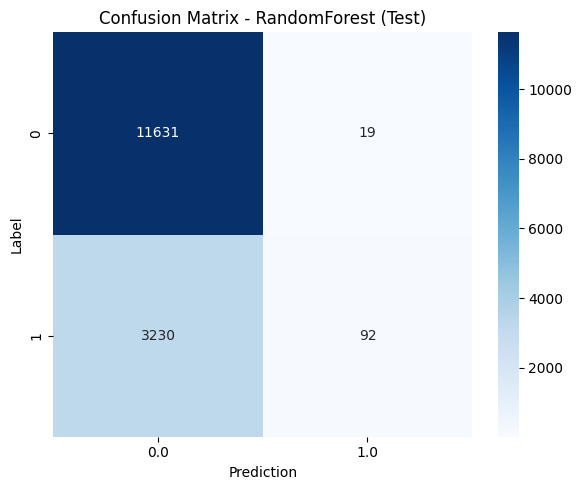

349

In [1]:
from pathlib import Path
import json
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
spark=(SparkSession.builder.appName('04_02_rf_cls').master('local[2]').config('spark.sql.shuffle.partitions','16').getOrCreate())
spark.sparkContext.setLogLevel('WARN')
PROJECT_ROOT=Path.cwd().resolve().parent if Path.cwd().name=='notebooks' else Path.cwd().resolve()
FEATURE_DIR=PROJECT_ROOT/'data'/'processed'/'features'
MODEL_DIR=PROJECT_ROOT/'models'/'classification'/'random_forest'
METRIC_DIR=PROJECT_ROOT/'reports'/'model_metrics'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRIC_DIR.mkdir(parents=True, exist_ok=True)
train_df=spark.read.parquet(str(FEATURE_DIR/'classification_train')).select('order_id','label','features').dropna()
val_df=spark.read.parquet(str(FEATURE_DIR/'classification_val')).select('order_id','label','features').dropna()
test_df=spark.read.parquet(str(FEATURE_DIR/'classification_test')).select('order_id','label','features').dropna()
rf=RandomForestClassifier(featuresCol='features',labelCol='label',numTrees=120,maxDepth=12,seed=42)
m=rf.fit(train_df)
pred_val=m.transform(val_df)
pred_test=m.transform(test_df)
val_f1=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='f1').evaluate(pred_val)
val_acc=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='accuracy').evaluate(pred_val)
test_f1=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='f1').evaluate(pred_test)
test_acc=MulticlassClassificationEvaluator(labelCol='label',predictionCol='prediction',metricName='accuracy').evaluate(pred_test)
metrics={'model_family':'classification','model_name':'RandomForestClassifier','val_f1':float(val_f1),'val_accuracy':float(val_acc),'f1':float(test_f1),'accuracy':float(test_acc),'test_f1':float(test_f1),'test_accuracy':float(test_acc),'train_rows':train_df.count(),'val_rows':val_df.count(),'test_rows':test_df.count()}
print(metrics)
display(pd.DataFrame([metrics]))
cm_pdf=pred_test.groupBy('label','prediction').count().toPandas()
if not cm_pdf.empty:
    cm_table=cm_pdf.pivot(index='label', columns='prediction', values='count').fillna(0).sort_index().sort_index(axis=1)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_table, annot=True, fmt='.0f', cmap='Blues')
    plt.title('Confusion Matrix - RandomForest (Test)')
    plt.xlabel('Prediction')
    plt.ylabel('Label')
    plt.tight_layout()
    plt.show()
m.write().overwrite().save(str(MODEL_DIR))
(METRIC_DIR/'classification_random_forest.json').write_text(json.dumps(metrics,indent=2),encoding='utf-8')